In [3]:
import celltypist  ## Import celltypist to perform automated cell type annotation using pre-trained models
import scanpy as sc   ## Import scanpy, the primary toolkit for analyzing single-cell RNA-seq data in Python

print("CellTypist and Scanpy loaded successfully!") 

CellTypist and Scanpy loaded successfully!


In [4]:
# Import pandas to handle data manipulation and analysis, 
# especially for managing cell metadata (obs) and gene information (var) as DataFrames
import pandas as pd

In [5]:
import warnings   ## Import the warnings module to manage and silence non-critical system alerts

# Suppress PerformanceWarnings from pandas, which often occur when highly 
# fragmented DataFrames are created during large-scale single-cell data processing
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)  

In [6]:
 # Import the os module to interact with the operating system, 
# allowing for file path management and directory navigation
import os

In [7]:
##ad is reserved for AnnData (the library that handles the data structure Scanpy uses).
import scanpy as ad ## Import scanpy using the 'ad' alias 

In [8]:
# Set the current working directory to the specified folder for saving plots
os.chdir("D:/Bidya Work/single/GSE183276/plots/celltypist_plots")
os.getcwd()                                   

'D:\\Bidya Work\\single\\GSE183276\\plots\\celltypist_plots'

In [9]:
# Load the AnnData object from a specific file path
# This file likely contains pre-calculated PCA and UMAP coordinates from a Seurat-to-Scanpy conversion
GSE183276_raw_adata = ad.read_h5ad("D:/Bidya Work/single/GSE183276/output/03_GSE183276_seurat_pca_umap.h5ad")
GSE183276_raw_adata

AnnData object with n_obs × n_vars = 5405 × 16442
    obs: 'Sample', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'percent.mt', 'percent.rb', 'mahal_dist_nCount', 'title', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1.1', 'characteristics_ch1.2', 'characteristics_ch1.3', 'characteristics_ch1.4', 'characteristics_ch1.5', 'characteristics_ch1.6', 'characteristics_ch1.7', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1.1', 'taxid_ch1', 'description', 'description.1', 'description.2', 'description.3', 'data_processing', 'data_processing.1', 'data_processing.2', 'data_processing.3', 'data_processing.4', 'data_processing.5', 'data_processing.6', 'platform_id', 'contact_name', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip.postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_s

In [10]:
# Importing the batch-corrected single-cell RNA-seq data (GSE183276) 
# The 'harmony_corrected' suffix indicates that batch effects between samples have been removed.
GSE183276_harmony_adata = ad.read_h5ad("D:/Bidya Work/single/GSE183276/output/04_GSE183276_harmony_corrected.h5ad")
GSE183276_harmony_adata

AnnData object with n_obs × n_vars = 5405 × 16442
    obs: 'Sample', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'percent.mt', 'percent.rb', 'mahal_dist_nCount', 'title', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1.1', 'characteristics_ch1.2', 'characteristics_ch1.3', 'characteristics_ch1.4', 'characteristics_ch1.5', 'characteristics_ch1.6', 'characteristics_ch1.7', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1.1', 'taxid_ch1', 'description', 'description.1', 'description.2', 'description.3', 'data_processing', 'data_processing.1', 'data_processing.2', 'data_processing.3', 'data_processing.4', 'data_processing.5', 'data_processing.6', 'platform_id', 'contact_name', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip.postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_s

(5405, 2)


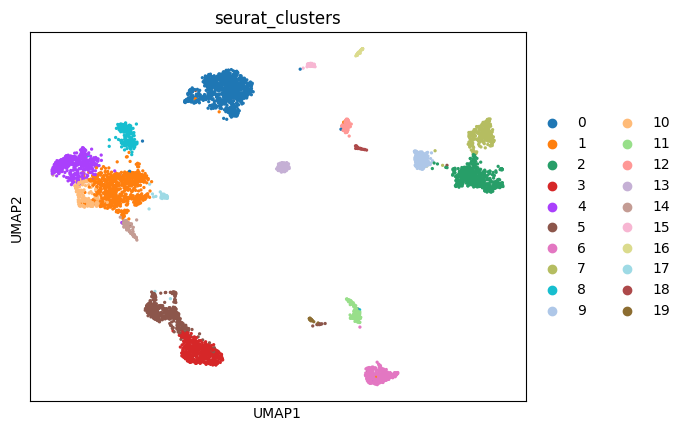

In [11]:
import pandas as pd
import numpy as np

# 1. Load the external UMAP coordinates ( exported from Seurat in R)
# Setting index_col=0 ensures the cell barcodes are used as the index for matching
umap_df = pd.read_csv(
    "D:/Bidya Work/single/GSE183276/GSE183276_umap_coordinates.csv",
    index_col=0
)

# 2. Verify dimensions: ensure the number of cells (5405) and coordinates (2) match expectations
print(umap_df.shape)   # should be (5405, 2)

# 3. Align and inject coordinates into the AnnData object
# We use .loc[GSE183276_harmony_adata.obs_names] to ensure the UMAP rows 
# match the exact order of cells in our AnnData object.
GSE183276_harmony_adata.obsm['X_umap'] = umap_df.loc[
    GSE183276_harmony_adata.obs_names
].values

# 4. Visualize the data using the newly injected Seurat UMAP coordinates
sc.pl.umap(
    GSE183276_harmony_adata,
    color='seurat_clusters',
    show=True
)

In [12]:
#In an AnnData object, the .X attribute is the "active" matrix. Most functions look at .X by default.
#The .layers slot: Usually acts as a container for different versions of your data (e.g., raw, normalized, logcounts).
#The .copy() requirement: Without .copy(), Python might just create a "view" (a shortcut). If you then modify .X, you might accidentally modify your saved logcounts layer too. Copying keeps them separate and safe.
GSE183276_harmony_adata.X = GSE183276_harmony_adata.layers['logcounts'].copy()

In [13]:
#You are using the batch-corrected Harmony embeddings to group cells and then applying a pre-trained model to "name" those groups.
import scanpy as sc
import celltypist

# 1. Define cell-to-cell relationships based on corrected data
# We use 'HARMONY' instead of the default PCA to ensure the graph as it reflects the batch-corrected space.
sc.pp.neighbors(GSE183276_harmony_adata, use_rep='HARMONY')

# 2. Group cells into high-resolution clusters
# A resolution of 10 is very high (over-clustering); this creates many small 
# sub-groups to help CellTypist make more precise 'majority voting' decisions.
sc.tl.leiden(GSE183276_harmony_adata, resolution=10, key_added='celltypist_clusters')

# 3. Predict cell types using the CellTypist model
# We use a specific Kidney model and 'majority_voting', which assigns a single 
# cell type to an entire cluster based on the most frequent prediction.
ct_pred = celltypist.annotate(
    GSE183276_harmony_adata,
    model='D:/Bidya Work/single/GSE183276/Adult_Human_Kidney.pkl',
    majority_voting=True,
    over_clustering='celltypist_clusters'
)

# 4. View the results
print(ct_pred.predicted_labels.head())

🔬 Input data has 5405 cells and 16442 genes
🔗 Matching reference genes in the model
🧬 9164 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


                                         predicted_labels over_clustering  \
GSM5554468_AKI3010018_AAACCCACAGGGATAC-1              aPT              21   
GSM5554468_AKI3010018_AAAGTGACACGGATCC-1              aPT              37   
GSM5554468_AKI3010018_AAAGTGAGTGGAAATT-1              aPT              21   
GSM5554468_AKI3010018_AAAGTGATCCGTAGTA-1             aTAL              26   
GSM5554468_AKI3010018_AACAAGACACTACCGG-1             aTAL              39   

                                         majority_voting  
GSM5554468_AKI3010018_AAACCCACAGGGATAC-1             aPT  
GSM5554468_AKI3010018_AAAGTGACACGGATCC-1             aPT  
GSM5554468_AKI3010018_AAAGTGAGTGGAAATT-1             aPT  
GSM5554468_AKI3010018_AAAGTGATCCGTAGTA-1            aTAL  
GSM5554468_AKI3010018_AACAAGACACTACCGG-1            aTAL  


In [14]:
# Count and display the total number of clusters generated by the high-resolution Leiden clustering.
# This helps verify if the 'over-clustering' worked as intended for CellTypist.
print(f"Number of clusters created: {len(GSE183276_harmony_adata.obs['celltypist_clusters'].unique())}")

Number of clusters created: 81


In [15]:
# Transfer the 'majority voting' predictions from the CellTypist result to the AnnData object.
# We convert to string (.astype(str)) to ensure compatibility with Scanpy's plotting functions.
GSE183276_harmony_adata.obs['majority_voting'] = (
    ct_pred.predicted_labels['majority_voting']
    .astype(str)
)

In [16]:
# Calculate and display the top 5 most frequent cell types identified by majority voting.
# This provides a quick census of the major cell populations in the dataset
print(GSE183276_harmony_adata.obs['majority_voting'].value_counts().head())

majority_voting
aTAL      915
PC        819
aPT       533
EC-PTC    524
C-TAL     488
Name: count, dtype: int64


... storing 'majority_voting' as categorical


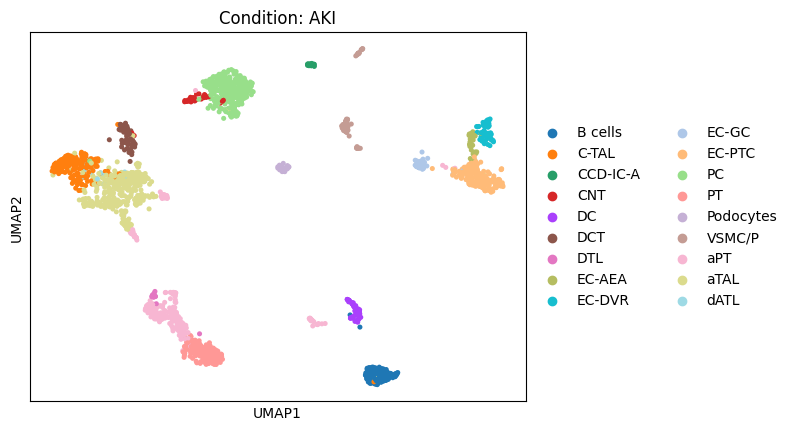

... storing 'majority_voting' as categorical


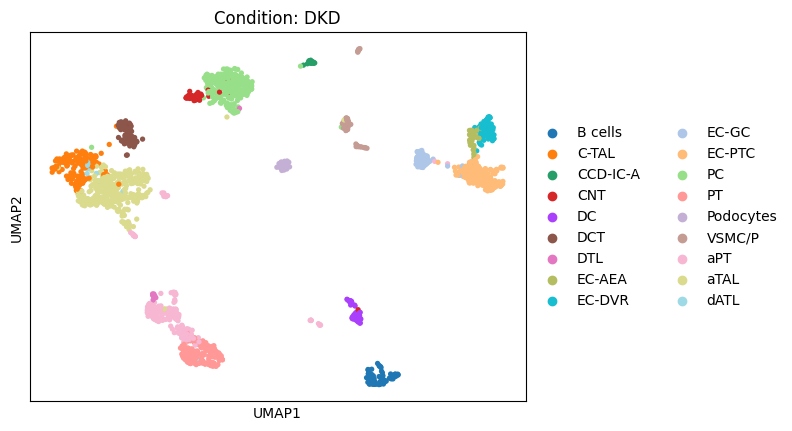

... storing 'majority_voting' as categorical


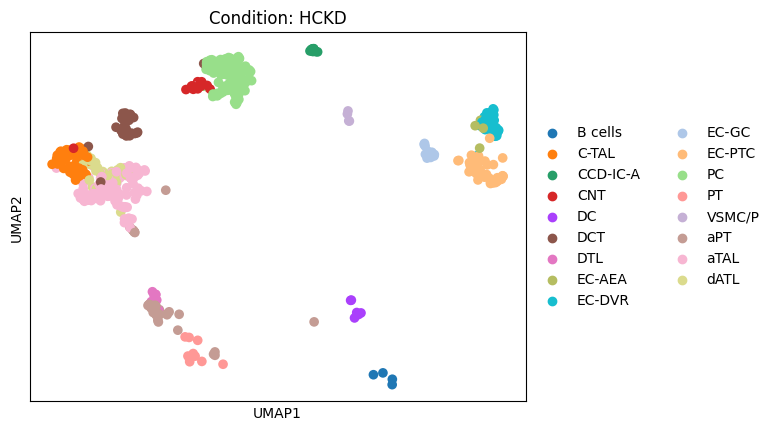

... storing 'majority_voting' as categorical


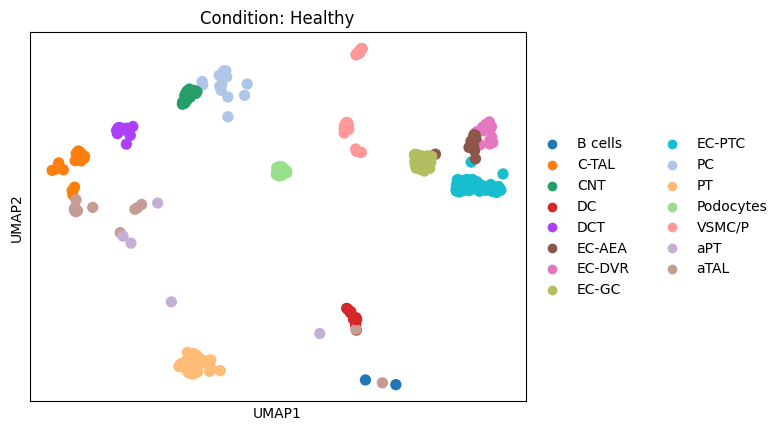

In [20]:
import os
import matplotlib.pyplot as plt
import scanpy as sc

# Create output directory if it doesn't exist
out_dir = "D:/Bidya Work/single/GSE183276/plots/celltypist_plots/"
os.makedirs(out_dir, exist_ok=True)

# Iterate through each unique group in the 'Condition' column
for cond in GSE183276_harmony_adata.obs['Condition'].unique():

    # Generate a UMAP plot for a subset of the data belonging to the current condition
    adata_subset = GSE183276_harmony_adata[
        GSE183276_harmony_adata.obs['Condition'] == cond
    ]

    fig = sc.pl.umap(
        adata_subset,
        color='majority_voting',   # Color cells by CellTypist predicted labels
        title=f'Condition: {cond}',   # Dynamically set the title
        legend_loc='right margin',
        show=False,         # Don't show immediately so we can save it first
        return_fig=True     # Capture the figure object for saving
    )

    # Save the figure for each condition
    fig.savefig(
        os.path.join(out_dir, f"umap_celltypes_ct_{cond}.png"),
        dpi=300,
        bbox_inches='tight'
    )

    # Show the plot
    plt.show()

    # Close figure to free memory
    plt.close(fig)

In [33]:
# Verify that the variable is a valid AnnData object.
# This confirms the data was loaded correctly into the Scanpy-compatible format.
print(type(GSE183276_harmony_adata))

<class 'anndata._core.anndata.AnnData'>


In [22]:
##This block of code is a troubleshooting and refinement step. You are renaming your coordinates to follow Scanpy’s naming conventions 
##and then re-running the clustering to ensure the automated annotation tool (CellTypist) has the best possible input.
import scanpy as sc
import celltypist

# 1. Standardize coordinate naming
# Scanpy functions look for 'X_pca' by default. This clones the existing 'PCA' 
# slot into 'X_pca' to ensure compatibility with downstream tools.
GSE183276_raw_adata.obsm['X_pca'] = GSE183276_raw_adata.obsm['PCA']

# 2. Re-calculate clusters for annotation
# We build a new neighborhood graph from the PCA and use high-resolution 
# Leiden clustering (over-clustering) to create fine-grained groups for prediction.
sc.pp.neighbors(GSE183276_raw_adata, use_rep='X_pca')
sc.tl.leiden(GSE183276_raw_adata, resolution=10, key_added='ct_clusters')

# 3. Perform automated cell type annotation
# CellTypist uses the model to predict labels and then 'smoothes' those 
# labels by applying a majority vote within each 'ct_cluster'.
GSE183276_predictions3 = celltypist.annotate(
    GSE183276_raw_adata, 
    model="D:/Bidya Work/single/GSE183276/Adult_Human_Kidney.pkl",
    majority_voting=True,
    over_clustering='ct_clusters'
)

# 4. Finalize the data object
# Cast the predictions to strings and save them into the metadata (.obs) 
# for easy plotting and data export.
GSE183276_raw_adata.obs["majority_voting"] = GSE183276_predictions3.predicted_labels["majority_voting"].astype(str)

print("Annotation complete!")


🔬 Input data has 5405 cells and 16442 genes
🔗 Matching reference genes in the model
🧬 9164 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


Annotation complete!


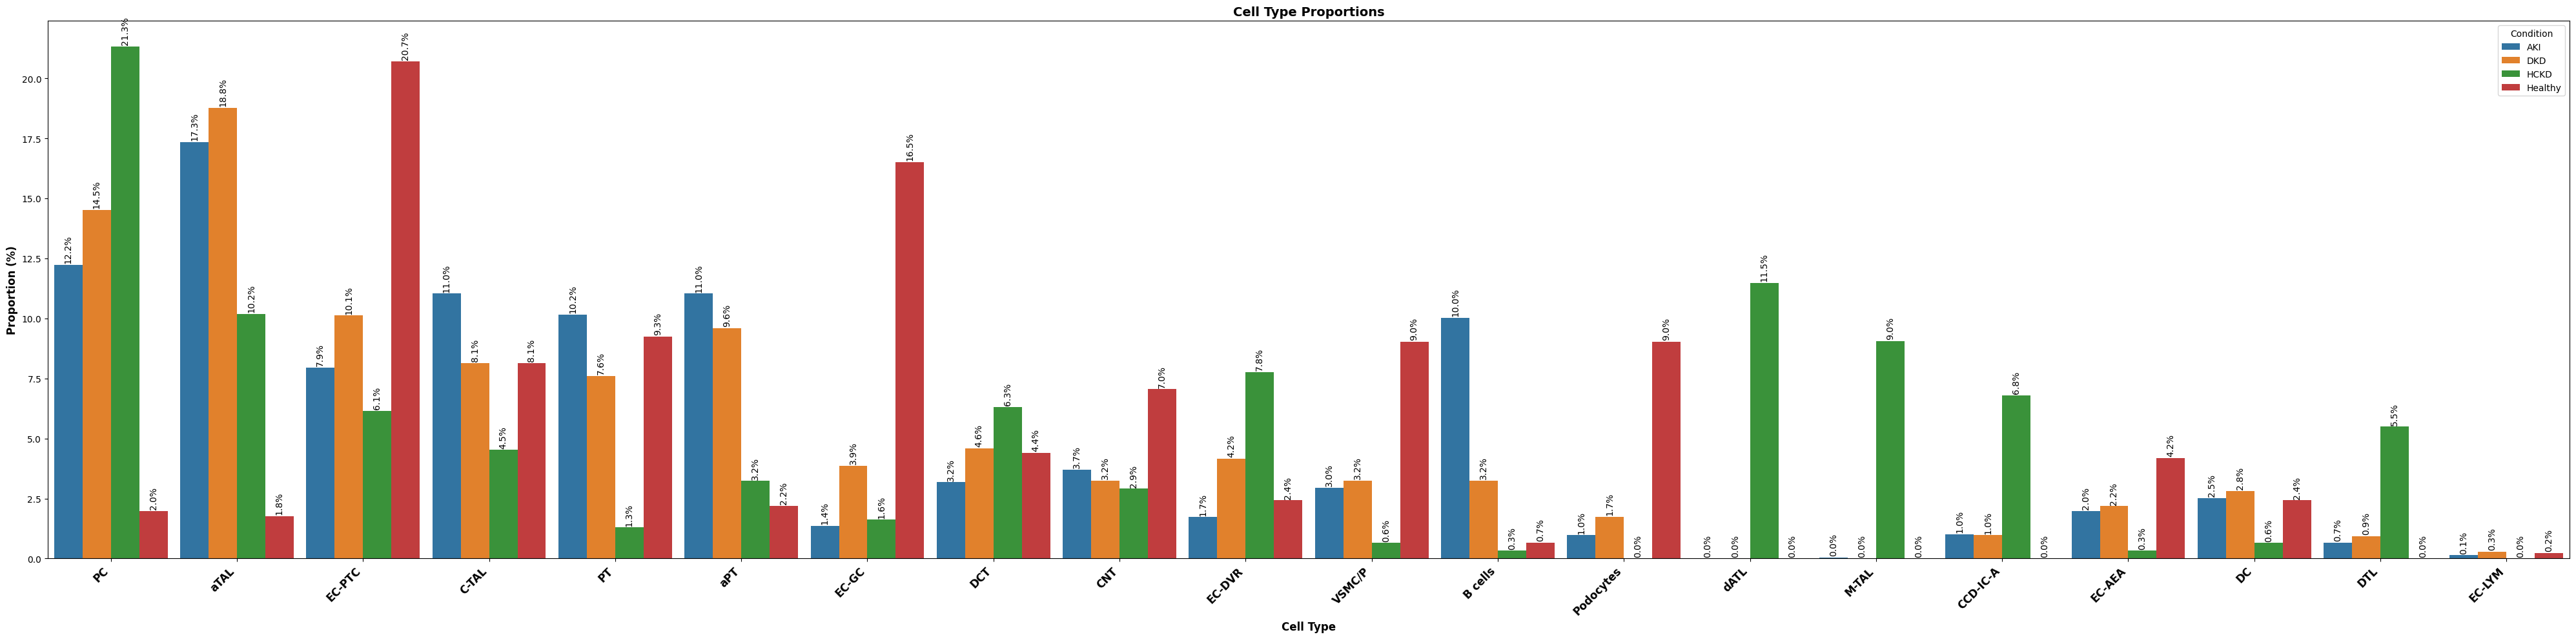

In [25]:
##This code performs a compositional analysis, which is a fancy way of saying it calculates which cell types are increasing or decreasing between your experimental conditions.
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Quantify the number of cells for each cell type within each condition
# This creates a summary table of raw counts
n_cells_condition = (
    GSE183276_raw_adata.obs
    .groupby(["Condition", "majority_voting"])
    .size()
    .reset_index(name="count")
)

# Step 2: Normalize counts to percentages (Proportions)
# This allows for fair comparison even if one condition has more total cells than another
n_cells_condition["total"] = n_cells_condition.groupby("Condition")["count"].transform("sum")
n_cells_condition["proportion"] = (n_cells_condition["count"] / n_cells_condition["total"]) * 100

# Step 3: Sort cell types by abundance
# We find the average percentage of each cell type across all conditions to order the plot
avg_proportions = (
    n_cells_condition
    .groupby("majority_voting")["proportion"]
    .mean()
    .sort_values(ascending=False)
)
ordered_celltypes = avg_proportions.index.tolist()

# Step 4: Generate the Bar Plot
# 'dodge=True' places the condition bars side-by-side for easy comparison
plt.figure(figsize=(40, 10))
ax = sns.barplot(
    data=n_cells_condition,
    x="majority_voting",
    y="proportion",
    hue="Condition",
    order=ordered_celltypes,
    dodge=True,
    width=0.9
)

# Step 5: Add percentage labels above the bars
# This makes the exact values readable without looking at the axis
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=10, rotation = 90)

# Customize axes
plt.xticks(rotation=45, ha="right", fontsize=12, fontweight="bold")
plt.ylabel("Proportion (%)", fontsize=12, fontweight="bold")
plt.xlabel("Cell Type", fontsize=12, fontweight="bold")
plt.title("Cell Type Proportions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Bidya Work/single/GSE183276/plots/celltypist_plots/Cellproportions_barplot.png", dpi=300, bbox_inches='tight')
plt.show()

n_cells_condition.to_csv("Cellproportions.csv", index=False)

In [26]:
# Create a new combined label by merging the predicted cell type with the condition.
# Resulting format: "CellType_Condition" (e.g., "Podocyte_Healthy").
# This is useful for performing differential expression between conditions within the same cell type.
GSE183276_raw_adata.obs['majority_voting'] = (
    GSE183276_raw_adata.obs['majority_voting'].astype(str)
    + "_" +
    GSE183276_raw_adata.obs['Condition'].astype(str)
)

In [27]:
def find_unique_markers(
    adata, 
    groupby='cell_type', 
    method='wilcoxon', 
    pval_threshold=0.05, 
    logfc_threshold=0.25,
    top_n=3,
    min_cells_per_group=2
):
    """
    Mimics Seurat's FindAllMarkers + filters for unique DEGs per cluster.
    
    Parameters:
        adata : AnnData object
        groupby : column in adata.obs to group cells (e.g., clusters, cell_type)
        method : DEG test method ('wilcoxon', 't-test', 'logreg')
        pval_threshold : adjusted p-value threshold for significance
        logfc_threshold : log fold change threshold for filtering

    Returns:
        unique_degs_df : DataFrame of DEGs unique to each group
    """

   # 1. Quality Control: Remove groups with too few cells to ensure statistical power
    group_counts = adata.obs[groupby].value_counts()
    valid_groups = group_counts[group_counts >= min_cells_per_group].index.tolist()

  # 2. Subset to valid data: Use .copy() to avoid modifying the original AnnData
    adata_filtered = adata[adata.obs[groupby].isin(valid_groups)].copy()
    
   # 3. Differential Expression Analysis: Compute rankings for all genes across groups
    sc.tl.rank_genes_groups(adata_filtered, groupby=groupby, method=method)
    
   # 4. Extract Results: Convert the structured numpy array into a tidy Pandas DataFrame
    all_degs = sc.get.rank_genes_groups_df(adata_filtered, group=None)
    
   # 5. Significance Filtering: Apply adjusted p-value and log-fold change cutoffs
    filtered_degs = all_degs[
        (all_degs['pvals_adj'] < pval_threshold) &
        (abs(all_degs['logfoldchanges']) > logfc_threshold)
    ]

  # 6. Exclusivity Check: Identify genes that passed filtering in ONLY ONE group.
    # This prevents 'Pan-marker' genes (like general immune markers) from appearing.
    unique_genes = (
        filtered_degs.groupby('names')['group']
        .nunique()
        .reset_index()
        .query('group == 1')['names']
        .tolist()
    )

   # 7. Final Subset: Keep only the genes identified as truly unique to a cluster
    unique_degs_df = filtered_degs[filtered_degs['names'].isin(unique_genes)].copy()


  # 8. Representative Selection: Sort by effect size (logFC) and pick the top N per group
    top_unique_degs_df = (
        unique_degs_df
        .sort_values(['group', 'logfoldchanges'], ascending=[True, False])
        .groupby('group')
        .head(top_n)
        .reset_index(drop=True)
    )

    return top_unique_degs_df

In [29]:
# 1. Identify the top 3 highly specific markers for each cell type
# Uses the Wilcoxon rank-sum test to find genes that are significant (p < 0.05) 
# and exclusive to only one group.unique_markers = find_unique_markers(
    GSE183276_raw_adata, 
    groupby='majority_voting',
    method='wilcoxon',
    pval_threshold=0.05, 
    logfc_threshold=0.25,
    top_n=3, 
    min_cells_per_group=2
)
# 2. Clean up group names using Regular Expressions (Regex)
# This removes redundant suffixes that might have been created during concatenation 
# (e.g., changing "Podocyte_Healthy_Healthy" back to "Podocyte_Healthy").
unique_markers['group'] = (
    unique_markers['group']
    .str.replace(r'_(HCKD|Healthy|AKI|DKD)_\1$', r'_\1', regex=True)
)

# 3. Validation and Export
# Print the top results, verify unique group names, and save to a CSV file.
print(unique_markers.head())
unique_markers['group'].drop_duplicates()

unique_markers.to_csv("Unique_cluster_markers.csv", index=False)

... storing 'majority_voting' as categorical


         group    names    scores  logfoldchanges         pvals     pvals_adj
0  B cells_AKI     ZBP1  7.779096        6.942462  7.304484e-15  2.852739e-13
1  B cells_AKI     LAX1  3.770616        6.590607  1.628453e-04  1.405513e-03
2  B cells_AKI  PKHD1L1  4.754852        6.425596  1.985920e-06  2.589413e-05
3  B cells_DKD    AMPD1  3.935986        6.573179  8.285572e-05  3.040879e-03
4  B cells_DKD    KLHL6  3.267116        5.491000  1.086491e-03  2.646532e-02


... storing 'majority_voting' as categorical


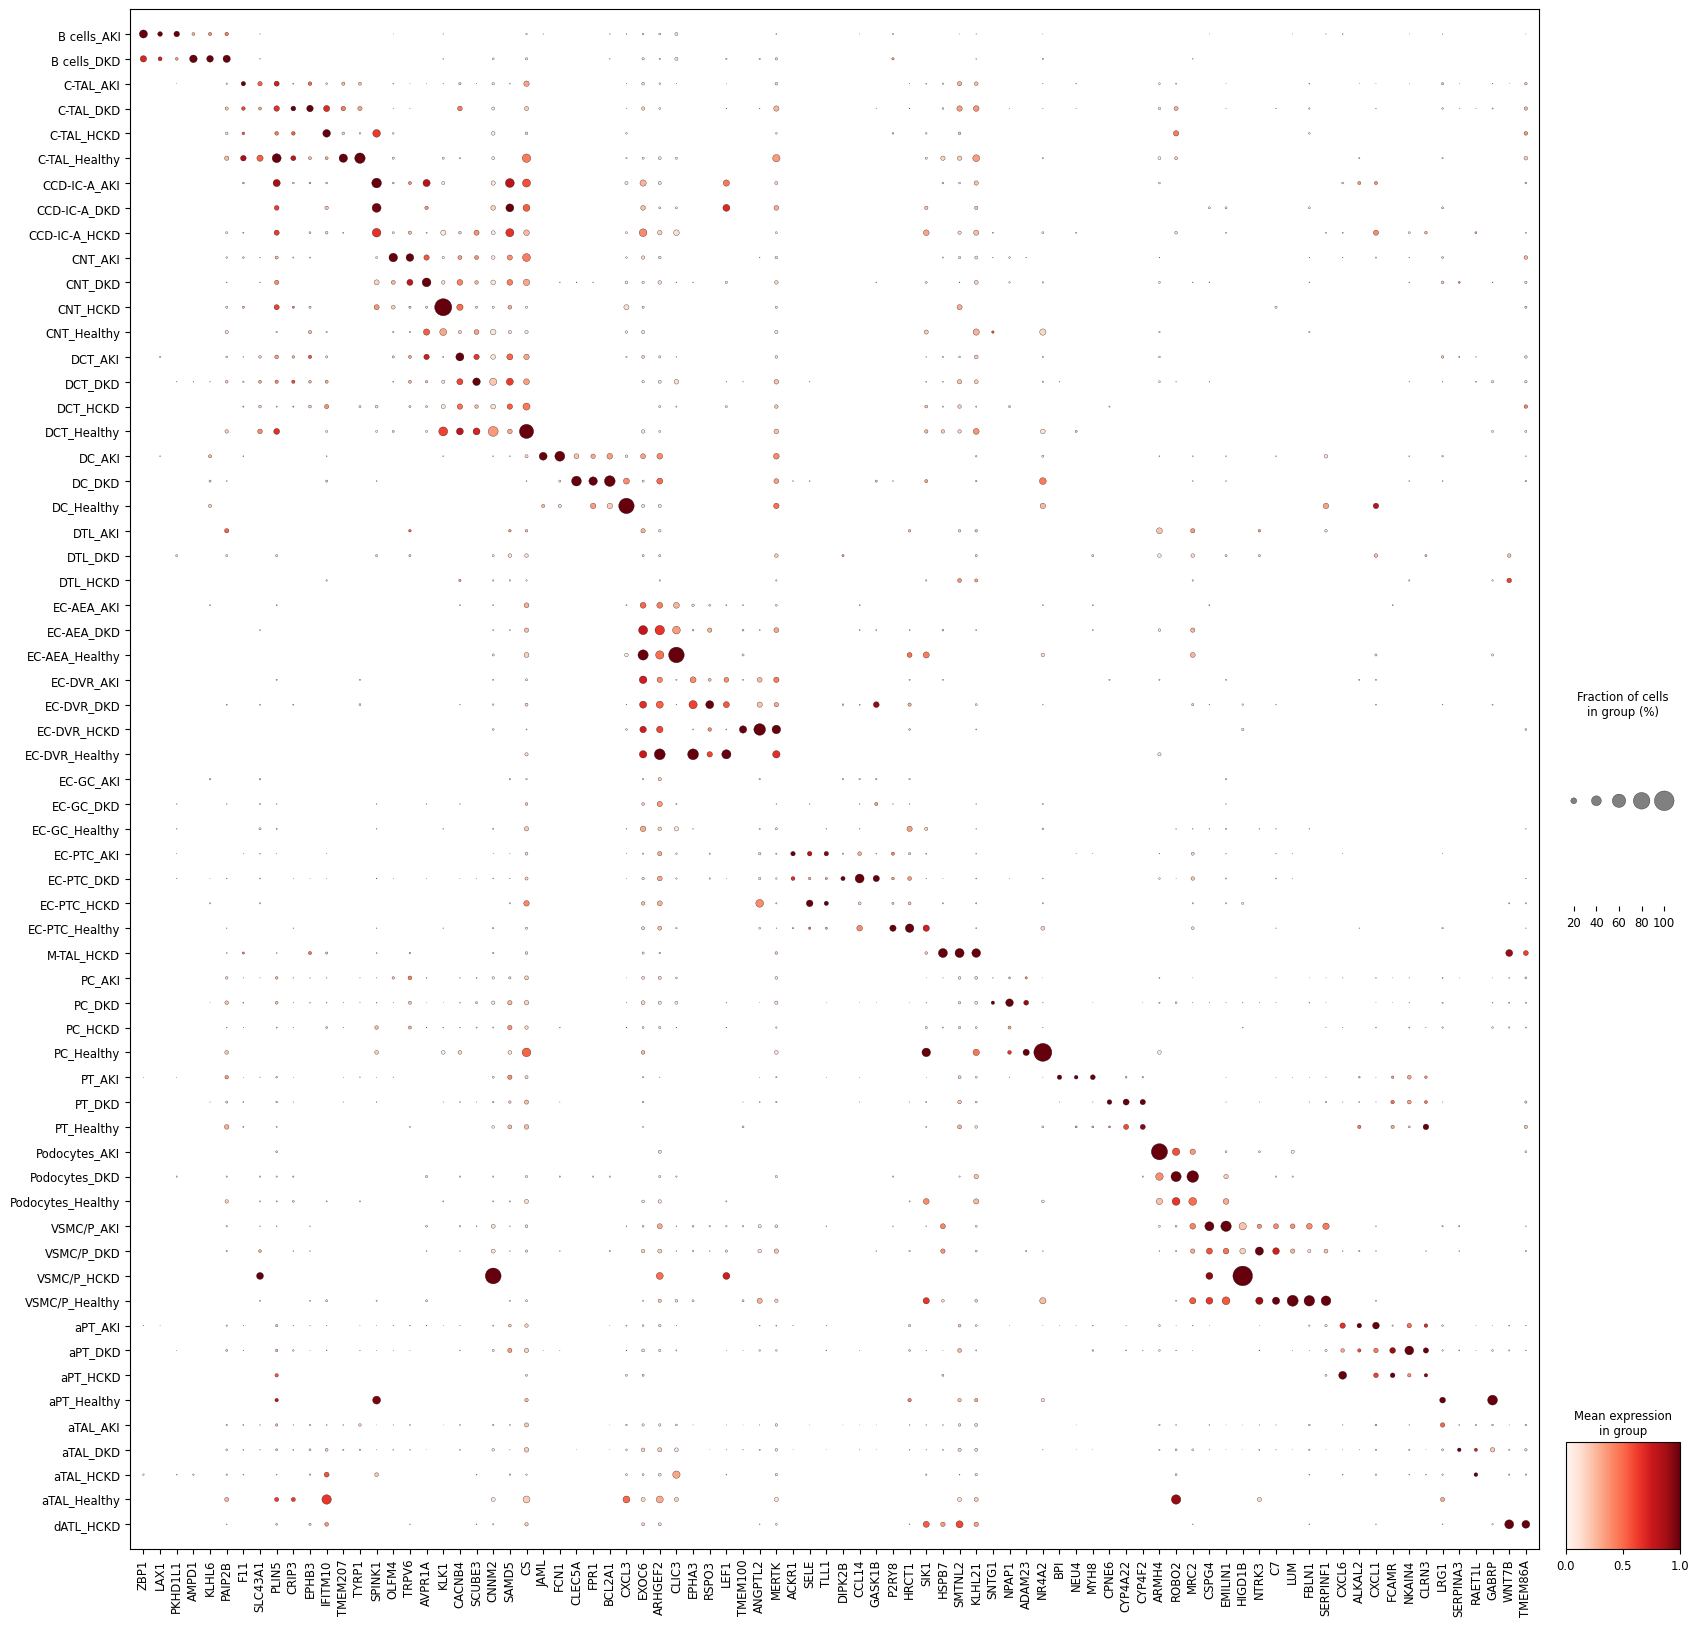

In [30]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# 1. Subset Data: Remove specific populations (e.g., Classical monocytes) 
# that might be redundant or distracting in this specific visualization.
excluded_prefixes = ["Classical monocytes"]
mask = ~GSE183276_raw_adata.obs['majority_voting'].str.startswith(tuple(excluded_prefixes))
adata_to_plot = GSE183276_raw_adata[mask].copy()

# 2. Filter Gene List: Ensure all selected markers actually exist in the matrix.
genes_to_plot = unique_markers["names"].tolist()  # top 3 per group
genes_to_plot = [g for g in genes_to_plot if g in adata_to_plot.var_names]

# 3. Data Transformation: Convert sparse matrix to dense array for calculation.
# This allows us to perform group-wise summation of gene expression.
X = adata_to_plot[:, genes_to_plot].X
if hasattr(X, "toarray"):  # sparse -> dense
    X = X.toarray()

# 4. Aggregation: Create a summary table of gene expression per cell-type group.
expr_df = pd.DataFrame(X, index=adata_to_plot.obs['majority_voting'], columns=genes_to_plot)
expr_per_group = expr_df.groupby(expr_df.index).sum()  # rows = groups, columns = genes

# 5. Stringent Filtering: Keep only genes with substantial total signal (sum >= 30).
# This removes "weak" markers that might be significant but aren't visually clear.
genes_filtered = expr_per_group.columns[(expr_per_group.max(axis=0) >= 30)].tolist()
expr_per_group = expr_per_group[genes_filtered]

# 6. Group Filtering: Ensure each group shown has a minimum total expression signal.
valid_groups = expr_per_group.index[(expr_per_group.sum(axis=1) > 20)].tolist()
adata_to_plot = adata_to_plot[adata_to_plot.obs['majority_voting'].isin(valid_groups)].copy()

# 7. Dot Plot Visualization:
# standard_scale='var' normalizes color from 0 to 1 for each gene, making it
# easier to see where each gene is uniquely "turned on."
sc.pl.dotplot(
    adata_to_plot,
    var_names=genes_filtered,
    groupby='majority_voting',
    standard_scale='var',
    show=False,
    figsize=(20, 20),
    dendrogram=False
)
plt.savefig("D:/Bidya Work/single/GSE183276/plots/celltypist_plots/Cluster_Markergenes.png", dpi=300, bbox_inches='tight')
plt.show()

In [32]:
GSE183276_raw_adata.write("D:/Bidya Work/single/GSE183276/output/GSE183276_celltypist.h5ad")